# Machine Learning

This script trains and evaluates model for:
1. Outbreak Classification (Will cases spike in 7/14 days?)
2. Case Count Forecasting (How many cases in 7/14/30 days?)

Models used:
1. Random Forest.
2. XGBoost
3. Logistic Regression


In [22]:
import os
import pandas as pd
from datetime import datetime
from pathlib import Path


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve, 
    mean_absolute_error, 
    mean_squared_error,
    r2_score
)
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [4]:
# Initial setup
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
df = pd.read_csv('../../data/ml/sample.csv')

df.head()


,report_date,geography_id,disease_id,country_code,region_name,outbreak_next_7d,outbreak_next_14d,cases_next_7d,cases_next_14d,cases_next_30d,...,population,population_density,urban_rural,year,month,quarter,day_of_week,day_of_year,is_rainy_season,created_at
0,2024-07-22,KE-NYA-094,Tuberculosis,NaN,NaN,0,0,3.0,1.0,2.0,...,NaN,NaN,NaN,2024,7,3,2,204,0,2026-01-06 09:27:37.522801+00:00
1,2024-01-20,NG-OTH-153,Malaria,NG,Others,0,0,2.0,1.0,5.0,...,419278.0,1080.61,Rural,2024,1,1,7,20,0,2026-01-06 09:27:37.522801+00:00
2,2024-10-15,KE-NAI-013,Malaria,NaN,NaN,0,1,48.0,38.0,20.0,...,NaN,NaN,NaN,2024,10,4,3,289,1,2026-01-06 09:27:37.522801+00:00
3,2024-01-22,NG-OYO-132,Malaria,NG,Oyo,0,0,2.0,1.0,2.0,...,7511634.0,40824.10,Urban,2024,1,1,2,22,0,2026-01-06 09:27:37.522801+00:00
4,2024-08-05,NG-LAG-103,Cholera,NG,Lagos,0,0,2.0,2.0,1.0,...,9914501.0,11636.74,Urban,2024,8,3,2,218,0,2026-01-06 09:27:37.522801+00:00


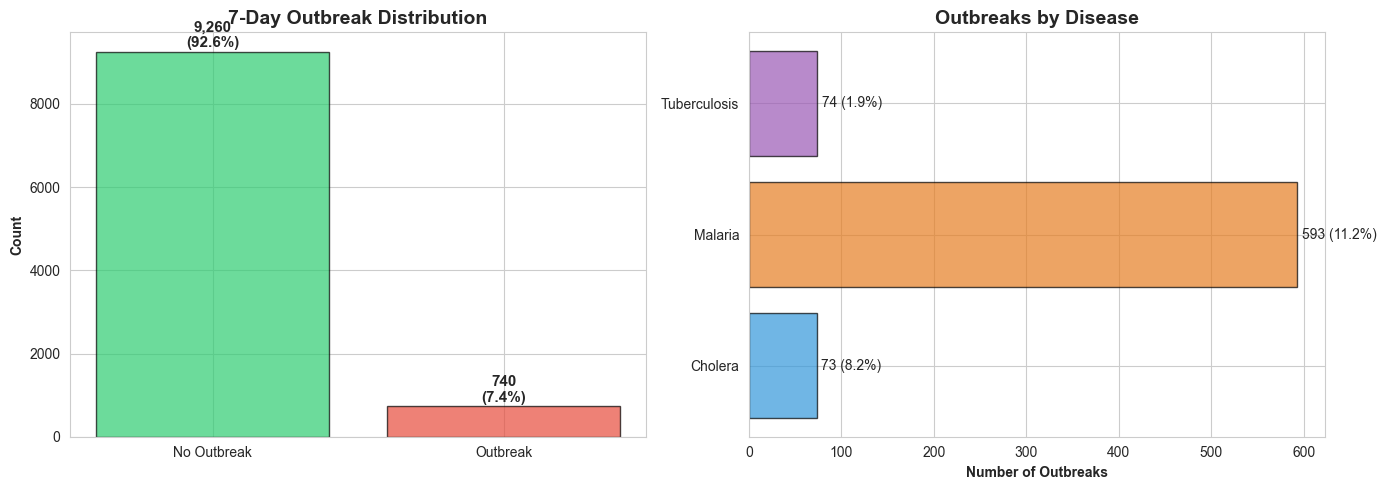

In [9]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
outbreak_counts = df['outbreak_next_7d'].value_counts()
axes[0].bar(
    ['No Outbreak', 'Outbreak'], 
    outbreak_counts.values, 
    color=['#2ecc71', '#e74c3c'], 
    alpha=0.7, 
    edgecolor='black'
)

axes[0].set_title('7-Day Outbreak Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
for i, v in enumerate(outbreak_counts.values):
    axes[0].text(i, v + 100, f"{v:,}\n({v/len(df):.1%})", ha='center', fontsize=11, fontweight='bold')


# By disease
disease_outbreaks = df.groupby('disease_id')['outbreak_next_7d'].agg(['sum', 'count'])
disease_outbreaks['rate'] = disease_outbreaks['sum'] / disease_outbreaks['count']
axes[1].barh(
    disease_outbreaks.index, 
    disease_outbreaks['sum'],
    color=['#3498db', '#e67e22', '#9b59b6'],
    alpha=0.7,
    edgecolor='black'
)
axes[1].set_title('Outbreaks by Disease', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Outbreaks', fontweight='bold')
for i, v in enumerate(disease_outbreaks['sum']):
    axes[1].text(v + 5, i, f"{v} ({disease_outbreaks['rate'].iloc[i]:.1%})", 
                va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../images/distribution.png')
plt.show()

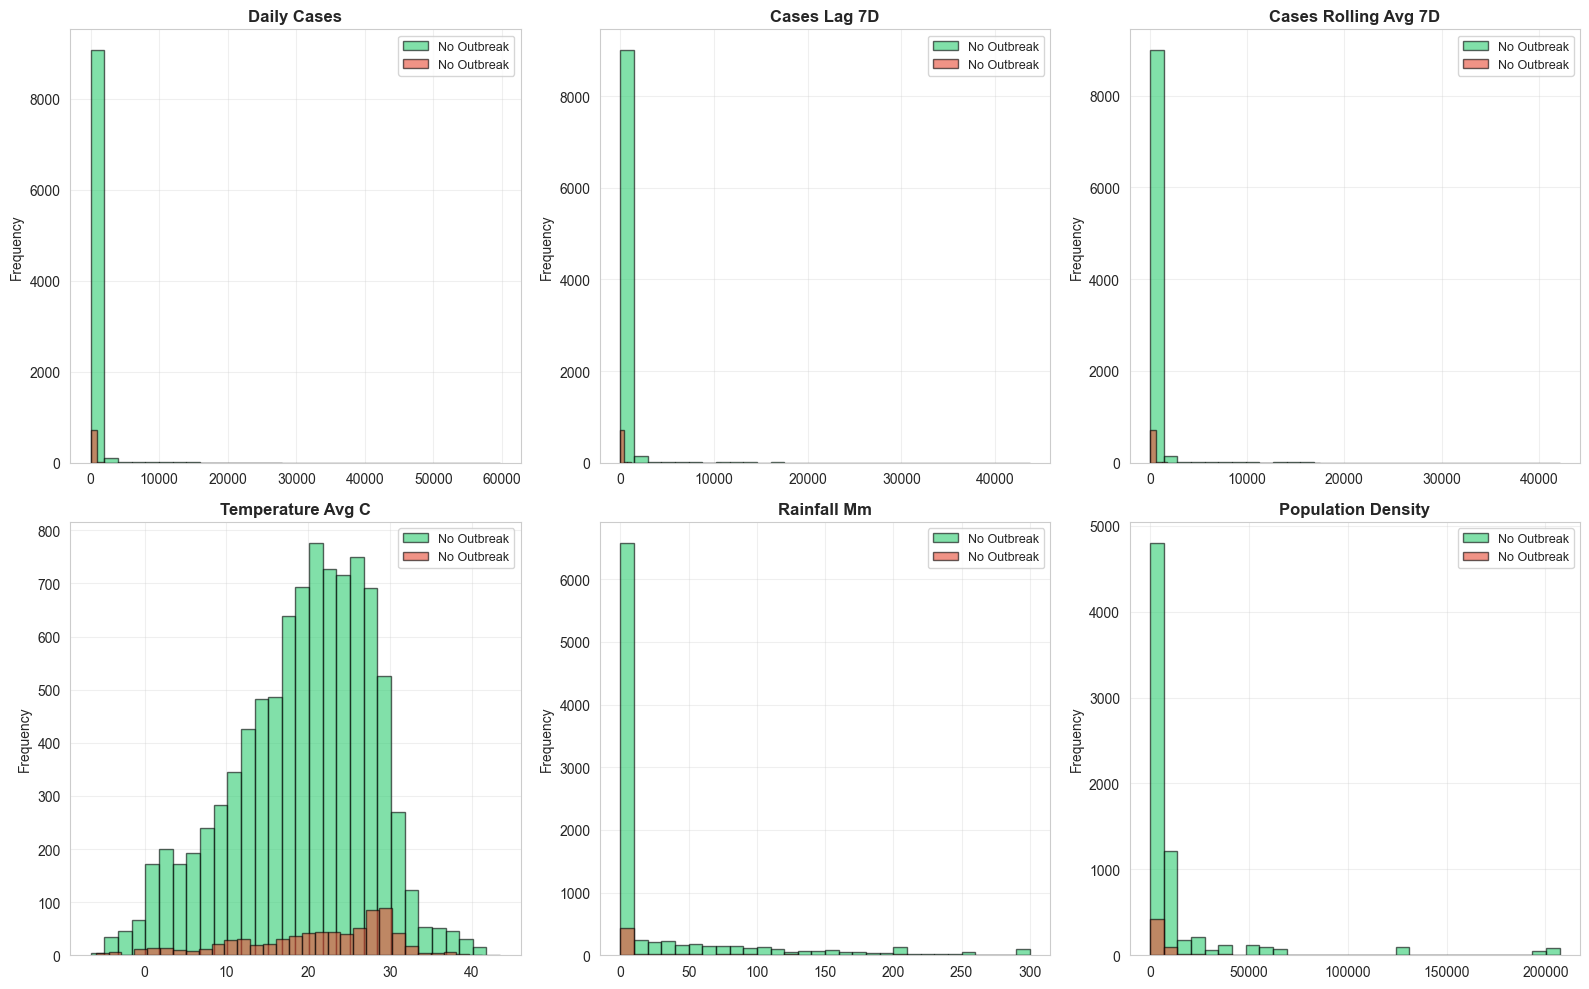

In [12]:
# Key feature statistics
key_features = ['daily_cases', 'cases_lag_7d', 'cases_rolling_avg_7d', 'temperature_avg_c', 'rainfall_mm', 'population_density']

# Feature distribution
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    outbreak = df[df['outbreak_next_7d'] == 1][feature].dropna()
    no_outbreak = df[df['outbreak_next_7d'] == 0][feature].dropna()

    axes[idx].hist(no_outbreak, bins=30, alpha=0.6, label='No Outbreak', color='#2ecc71', edgecolor='black')
    axes[idx].hist(outbreak, bins=30, alpha=0.6, label='No Outbreak', color='#e74c36', edgecolor='black')
    axes[idx].set_title(feature.replace('_', ' ').title(), fontweight='bold', fontsize=12)
    axes[idx].legend(fontsize=9)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Feature Preparation

In [27]:
# Define feature preparation
id_cols = ['report_date', 'geography_id', 'disease_id', 'country_code', 'region_name']
target_cols = ['ooutbreak_next_7d', 'outbreak_next_14d', 'cases_next_7d', 'cases_next_14d', 'cases_next_30d']
exclude_cols = id_cols + target_cols + ['created_at']
categorical_features = ['urban_rural'] if 'urban_rural' in df.columns else []
numeric_features = [
    col for col in df.columns
    if col not in exclude_cols
    and col not in categorical_features
    and df[col].dtype in ['float64', 'int64']
]

X = df[numeric_features].copy()

# Encode categorical features
if categorical_features:
    for col in categorical_features:
        if col in df.columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(df[col].fillna('Unknown'))


# Target variable
y = df['outbreak_next_7d']

# Metadata
metadata = df[id_cols].copy()

## Train/Test Split

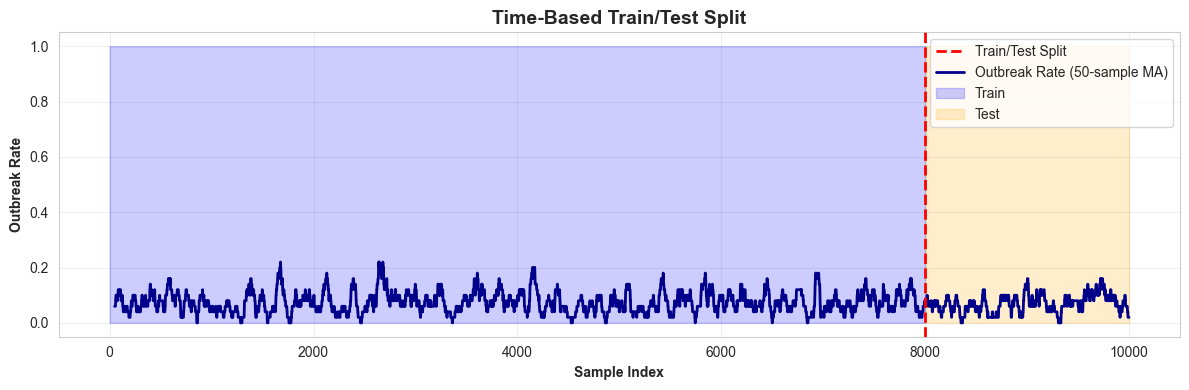

In [30]:
# Time-based split
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_test = X.iloc[split_idx:]
X_test = X_test.fillna(train_median)
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]
meta_train = metadata.iloc[:split_idx]
meta_test = metadata.iloc[split_idx:]

# Visualise the split
fig, ax = plt.subplots(figsize=(12, 4))
ax.axvline(x=split_idx, color='red', linestyle="--", linewidth=2, label='Train/Test Split', zorder=3)
ax.plot(
    range(len(y)),
    y.rolling(50).mean(),
    label='Outbreak Rate (50-sample MA)',
    linewidth=2,
    color='darkblue'
)
ax.fill_between(
    range(split_idx),
    0,
    1,
    alpha=0.2,
    color='blue',
    label='Train'
)
ax.fill_between(
    range(split_idx, len(y)),
    0,
    1,
    alpha=0.2,
    color='orange',
    label='Test'
)

ax.set_xlabel('Sample Index', fontweight='bold')
ax.set_ylabel('Outbreak Rate', fontweight='bold')
ax.set_title('Time-Based Train/Test Split', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/test-split-visual.png')
plt.show()

## Model Training

Best model: RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=20, n_jobs=-1, random_state=42) with an accuracy of 1.0 and ROC-AUC of 1.0


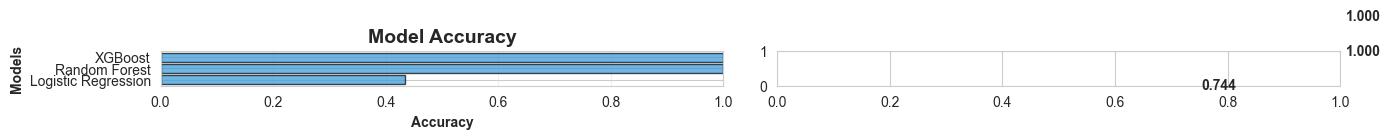

                 Model  Accuracy   ROC AUC
0  Logistic Regression     0.435  0.744042
1        Random Forest     1.000  1.000000
2              XGBoost     1.000  1.000000


In [33]:
# 1. Logistic Regression
models = {}
results = []

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

acc_lr = (y_pred_lr == y_test).mean()
auc_lr = roc_auc_score(y_test, y_prob_lr)

models['Logistic Regression'] = lr
results.append({'Model': 'Logistic Regression', 'Accuracy': acc_lr, 'ROC AUC': auc_lr})

# 2. Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = (y_pred_rf == y_test).mean()
auc_rf = roc_auc_score(y_test, y_prob_rf)

models['Random Forest'] = rf
results.append({'Model': 'Random Forest', 'Accuracy': acc_rf, 'ROC AUC': auc_rf})

# 3. XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train, verbose=False)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

acc_xgb = (y_pred_xgb == y_test).mean()
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

models['XGBoost'] = xgb_model
results.append({'Model': 'XGBoost', 'Accuracy': acc_xgb, 'ROC AUC': auc_xgb})

# Model comparison
results_df = pd.DataFrame(results)
best_idx = results_df['ROC AUC'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_model = models[best_model_name]

print(f"Best model: {best_model} with an accuracy of {results_df.loc[best_idx, 'Accuracy']} and ROC-AUC of {results_df.loc[best_idx, 'ROC AUC']}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(
    results_df['Model'],
    results_df['Accuracy'],
    color='#3498db',
    alpha=0.7,
    edgecolor='black'
)
axes[0].set_xlabel('Accuracy', fontweight='bold')
axes[0].set_ylabel('Models', fontweight='bold')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(results_df['ROC AUC']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(results_df)